In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)

import plotly.express as px
import plotly.graph_objects as go

# Data Collection

In [3]:
df = pd.read_csv("/content/sample_data/archive (8).zip")
print(df.head())
print(df.info())
print(df.shape)

  Student_ID Student_Age     Sex High_School_Type Scholarship Additional_Work  \
0   STUDENT1       19-22    Male            Other         50%             Yes   
1   STUDENT2       19-22    Male            Other         50%             Yes   
2   STUDENT3       19-22    Male            State         50%              No   
3   STUDENT4          18  Female          Private         50%             Yes   
4   STUDENT5       19-22    Male          Private         50%              No   

  Sports_activity Transportation  Weekly_Study_Hours Attendance Reading Notes  \
0              No        Private                   0     Always     Yes   Yes   
1              No        Private                   0     Always     Yes    No   
2              No        Private                   2      Never      No    No   
3              No            Bus                   2     Always      No   Yes   
4              No            Bus                  12     Always     Yes    No   

  Listening_in_Class Proje

# Data Cleaning & Preprocessing

In [7]:
print(df.isnull().sum())
df.drop_duplicates(inplace=True)
le = LabelEncoder()

categorical_cols = [
    "Sex"
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

Student_Age           0
Sex                   0
High_School_Type      0
Scholarship           1
Additional_Work       0
Sports_activity       0
Transportation        0
Weekly_Study_Hours    0
Attendance            0
Reading               0
Notes                 0
Listening_in_Class    0
Project_work          0
Grade                 0
dtype: int64


# Descriptive Statistics

In [9]:
print("Average Weekly Study Hours:")
print(df["Weekly_Study_Hours"].mean())

print("\nAttendance Distribution:")
print(df["Attendance"].value_counts())

print("\nGrade Distribution:")
print(df["Grade"].value_counts())

Average Weekly Study Hours:
2.3472222222222223

Attendance Distribution:
Attendance
Always       97
Sometimes    25
Never        21
3             1
Name: count, dtype: int64

Grade Distribution:
Grade
AA      35
BA      24
BB      20
CC      17
DD      17
DC      13
CB      10
Fail     8
Name: count, dtype: int64


# Student Performance Analysis

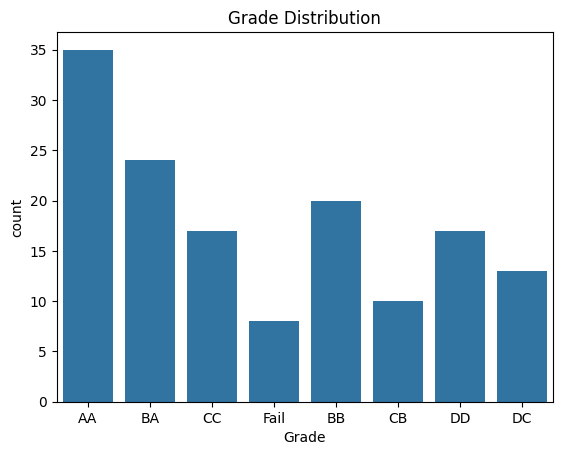

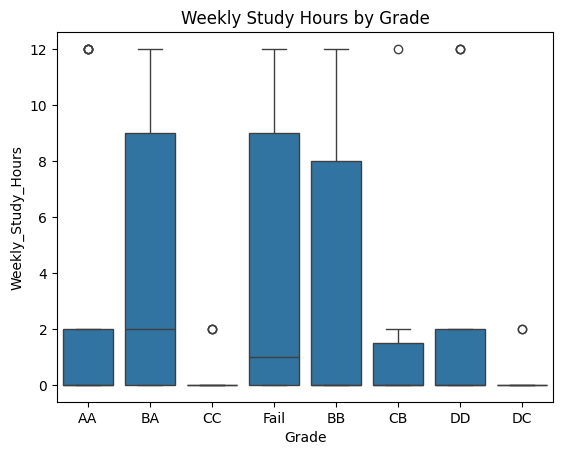

In [22]:
sns.countplot(x="Grade", data=df)
plt.title("Grade Distribution")
plt.show()
sns.boxplot(
    x="Grade",
    y="Weekly_Study_Hours",
    data=df
)
plt.title("Weekly Study Hours by Grade")
plt.show()

# Group-Based Analysis

In [28]:
gender_pass = pd.crosstab(
    df["Sex"],
    df["Grade"]
)

print(gender_pass)

Grade  AA  BA  BB  CB  CC  DC  DD  Fail
Sex                                    
0      16  12   7   5   6   4   0     8
1      19  12  13   5  11   9  17     0


# Relationship Analysis

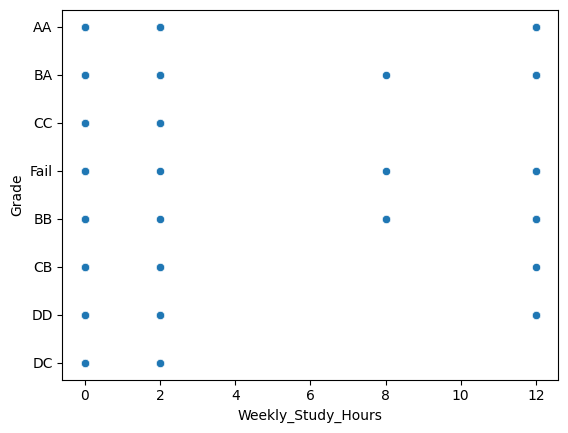

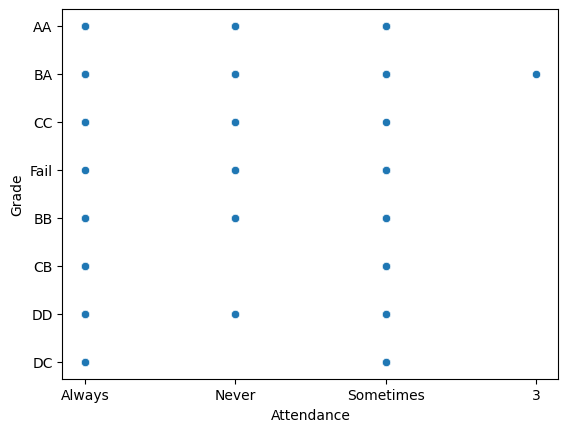

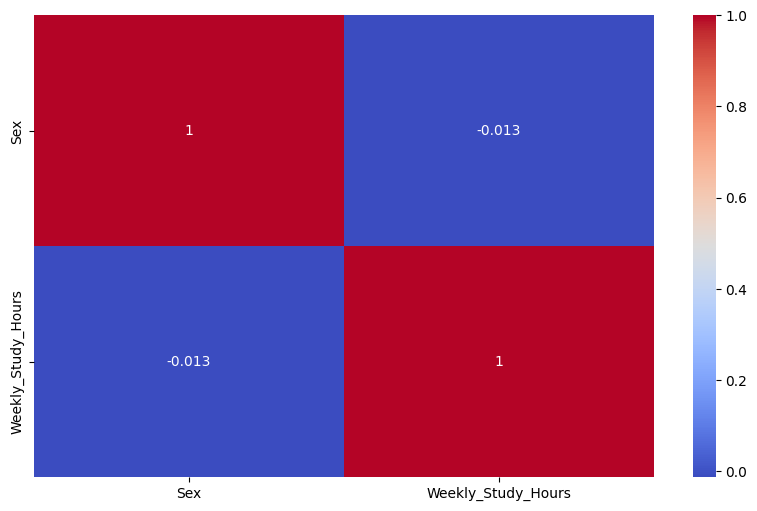

In [32]:
sns.scatterplot(
    x="Weekly_Study_Hours",
    y="Grade",
    data=df
)
plt.show()
sns.scatterplot(
    x="Attendance",
    y="Grade",
    data=df
)
plt.show()
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.show()

# Data Visualization

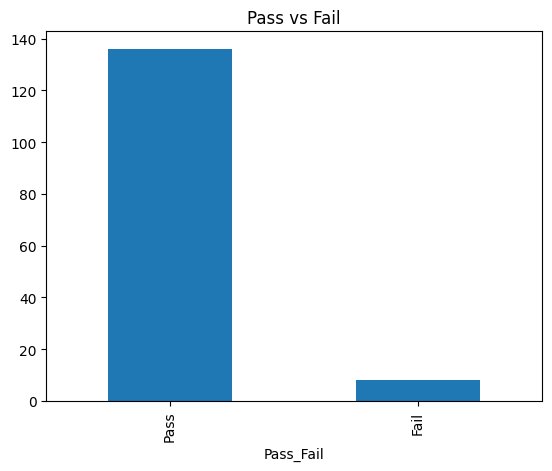

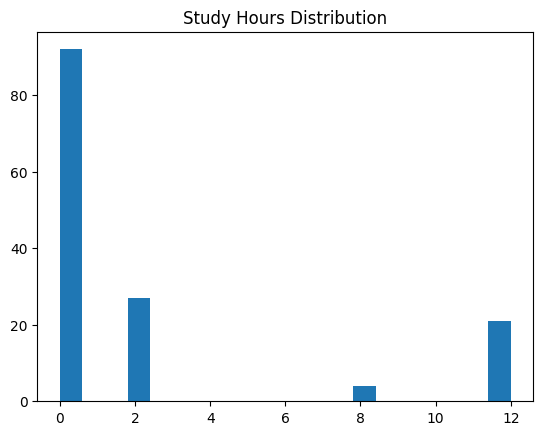

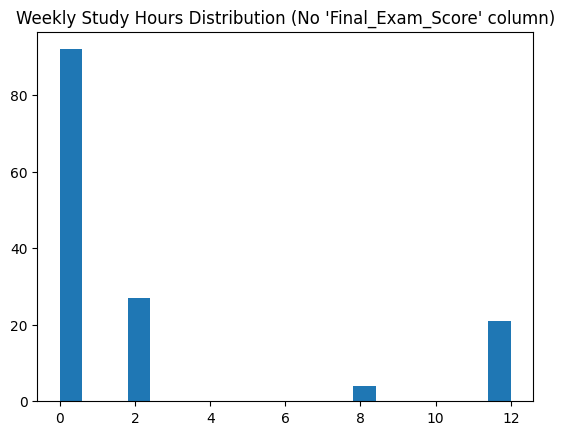

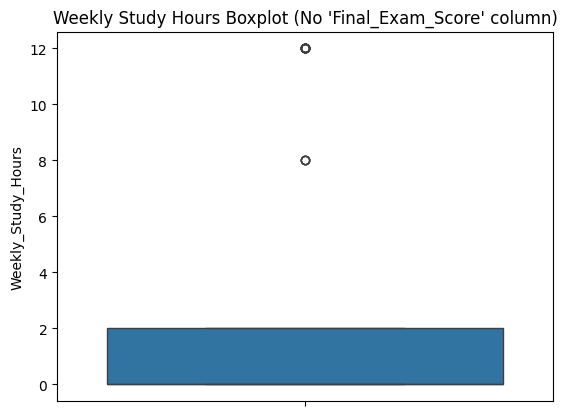

In [36]:

df['Pass_Fail'] = df['Grade'].apply(lambda x: 'Fail' if x == 'Fail' else 'Pass')
df["Pass_Fail"].value_counts().plot(
    kind="bar"
)
plt.title("Pass vs Fail")
plt.show()
plt.hist(
    df["Weekly_Study_Hours"],
    bins=20
)

plt.title("Study Hours Distribution")
plt.show()
plt.hist(
    df["Weekly_Study_Hours"],
    bins=20
)
plt.title("Weekly Study Hours Distribution (No 'Final_Exam_Score' column)")
plt.show()
sns.boxplot(
    y=df["Weekly_Study_Hours"]
)
plt.title("Weekly Study Hours Boxplot (No 'Final_Exam_Score' column)")
plt.show()

# Risk Analysis

In [39]:

def map_attendance_to_rate(attendance_status):
    if attendance_status == 'Always':
        return 90
    elif attendance_status == 'Sometimes':
        return 65
    elif attendance_status == 'Never':
        return 30
    elif attendance_status == '3':
        return 30
    else:
        return np.nan
df['Numerical_Attendance_Rate'] = df['Attendance'].apply(map_attendance_to_rate)
def risk_category(row):

    if pd.isna(row['Numerical_Attendance_Rate']):
        return "Unknown Risk (Attendance)"
    if (
        row["Numerical_Attendance_Rate"] < 60 and
        row["Weekly_Study_Hours"] < 10

    ):
        return "High Risk"

    elif (
        row["Numerical_Attendance_Rate"] < 75
    ):
        return "Medium Risk"

    else:
        return "Low Risk"


df["Risk_Category"] = df.apply(
    risk_category,
    axis=1
)

print(
    df["Risk_Category"].value_counts()
)

Risk_Category
Low Risk       97
Medium Risk    28
High Risk      19
Name: count, dtype: int64


# Predictive Modeling

In [46]:

current_df = df.copy()
columns_to_drop_from_X_initial = ["Pass_Fail", "Risk_Category"]
X = current_df.drop(columns=[col for col in columns_to_drop_from_X_initial if col in current_df.columns], axis=1)
columns_to_drop_from_X_further = ["Student_ID", "Attendance"]
X = X.drop(columns=[col for col in columns_to_drop_from_X_further if col in X.columns], axis=1)
X["Student_Age"] = X["Student_Age"].apply(
    lambda x: int(x.split('-')[0]) if isinstance(x, str) and '-' in x else int(x)
)
X['Scholarship'] = X['Scholarship'].astype(str).str.replace('%', '', regex=False).replace('No', '0').astype(float)
X['Scholarship'] = X['Scholarship'].fillna(X['Scholarship'].median())
categorical_cols_for_encoding = [
    "High_School_Type",
    "Additional_Work",
    "Sports_activity",
    "Transportation",
    "Reading",
    "Notes",
    "Listening_in_Class",
    "Project_work",
    "Grade"
]
for col in categorical_cols_for_encoding:
    if col in X.columns and X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col])
y = current_df["Pass_Fail"]
y = le.fit_transform(y)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)
model = LogisticRegression()
model.fit(
    X_train,
    y_train
)
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

# Model Evaluation

Accuracy: 0.896551724137931
Precision: 0.896551724137931
Recall: 1.0
F1 Score: 0.9454545454545454


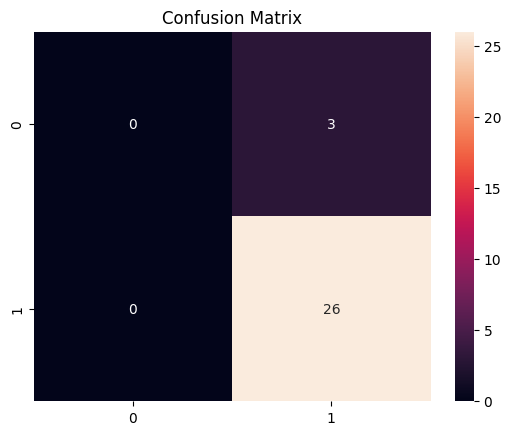

ROC AUC: 0.9871794871794872
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.90      1.00      0.95        26

    accuracy                           0.90        29
   macro avg       0.45      0.50      0.47        29
weighted avg       0.80      0.90      0.85        29



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [48]:
accuracy = accuracy_score(
    y_test,
    y_pred
)
print("Accuracy:", accuracy)
print(
    "Precision:",
    precision_score(y_test, y_pred)
)
print(
    "Recall:",
    recall_score(y_test, y_pred)
)
print(
    "F1 Score:",
    f1_score(y_test, y_pred)
)
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.show()
roc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC AUC:", roc)
print(
    classification_report(
        y_test,
        y_pred
    )
)

# Dashboard Creation

In [51]:
fig = px.histogram(
    df,
    x="Pass_Fail",
    title="Pass vs Fail Distribution"
)
fig.show()
fig = px.scatter(
    df,
    x="Weekly_Study_Hours",
    y="Pass_Fail",
    color="Pass_Fail",
    title="Weekly Study Hours vs Pass/Fail Outcome"
)
fig.show()
fig = px.scatter(
    df,
    x="Attendance",
    y="Pass_Fail",
    color="Pass_Fail",
    title="Attendance vs Pass/Fail Outcome"
)
fig.show()

fig = px.pie(
    df,
    names="Risk_Category",
    title="Student Risk Categories"
)
fig.show()

# Insights & Conclusion

In [54]:

df['Student_Age'] = df['Student_Age'].apply(
    lambda x: int(x.split('-')[0]) if isinstance(x, str) and '-' in x else int(x)
)
df['Scholarship'] = df['Scholarship'].astype(str).str.replace('%', '', regex=False).replace('No', '0').astype(float)
df['Scholarship'] = df['Scholarship'].fillna(df['Scholarship'].median())
df['Pass_Fail_encoded'] = le.fit_transform(df['Pass_Fail'])
print("Top Correlations With Pass/Fail Outcome")
print(
    df.corr(numeric_only=True)["Pass_Fail_encoded"]
    .sort_values(ascending=False)
)

Top Correlations With Pass/Fail Outcome
Pass_Fail_encoded            1.000000
Sex                          0.295332
Numerical_Attendance_Rate    0.190281
Student_Age                  0.112022
Scholarship                 -0.010845
Weekly_Study_Hours          -0.108719
Name: Pass_Fail_encoded, dtype: float64
